#Titanic
pada projek kali ini, kita akan mencoba membuat model prediksi untuk mengikuti kompetisi yang diselenggarakan oleh kaggle. kita akan memprediksi hasil jawaban yang nanti akan di upload ke Kaggle, nanti dari kaggle mengumumkan berapa skor akurasi hasil prediksinya.

In [1]:
# sebelum itu, kita import dulu library nya seperti biasa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None) #<----- ini untuk nampilin semua kolom di dataframe
sns.set_context('talk')
sns.set_style('whitegrid')
sns.set_palette('Blues_r')

In [2]:
# selanjutnya, import data csv nya dari drive. (DATA TRAIN)
sheet_url = 'https://docs.google.com/spreadsheets/d/1Bqk0DIDTjEJyBjs7af9UFMF8kiV-xC8rNzac6t0IqYY/edit?gid=0#gid=0'
sheet_url_trf = sheet_url.replace('/edit?gid=', '/export?format=csv&gid=')
print(sheet_url_trf)

#Bikin variable untuk membaca data yang udah di import tadi dengan menggunakan pandas
df_train = pd.read_csv(sheet_url_trf)
df_train.head()

https://docs.google.com/spreadsheets/d/1Bqk0DIDTjEJyBjs7af9UFMF8kiV-xC8rNzac6t0IqYY/export?format=csv&gid=0#gid=0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,712.833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S


In [3]:
# selanjutnya, import data csv nya dari drive. (DATA TEST)
sheet_url = 'https://docs.google.com/spreadsheets/d/1ESo_umV7YCE2nQwz79MhgTfVnHApp9tfAcVrjqF6Kw4/edit?gid=0#gid=0'
sheet_url_trf = sheet_url.replace('/edit?gid=', '/export?format=csv&gid=')
print(sheet_url_trf)

#Bikin variable untuk membaca data yang udah di import tadi dengan menggunakan pandas
df_test = pd.read_csv(sheet_url_trf)
df_test.head()

https://docs.google.com/spreadsheets/d/1ESo_umV7YCE2nQwz79MhgTfVnHApp9tfAcVrjqF6Kw4/export?format=csv&gid=0#gid=0


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,78.292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,96.875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,86.625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,122.875,NaN,S


##Cleaning Data

###Cek Kualitas Data
cek kesesuaian tipe data dan mngubahnya kalau misal ga sesuai. trus nyari tau jugag tentang mean max dan min dan lain-lainnya (dgn .describe())

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    object 
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 83.7+ KB


ada data null pada column 'Age', 'Cabin', dan 'Embarked'

In [5]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000


In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    object 
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 36.0+ KB


ada data null di 'Age', 'Fare' dan 'Cabin'

In [7]:
df_test.describe()


,PassengerId,Pclass,Age,SibSp,Parch
count,418.000000,418.000000,332.000000,418.000000,418.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344
std,120.810458,0.841838,14.181209,0.896760,0.981429
min,892.000000,1.000000,0.170000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000
50%,1100.500000,3.000000,27.000000,0.000000,0.000000
75%,1204.750000,3.000000,39.000000,1.000000,0.000000
max,1309.000000,3.000000,76.000000,8.000000,9.000000


In [8]:
df_train.shape

(891, 12)

In [9]:
df_test.shape

(418, 11)

###Cek Duplicate Data

In [10]:
df_train.duplicated().sum()

0

In [11]:
df_test.duplicated().sum()

0

###Cek Missing Value

In [12]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


df_train : Age, Cabin dan Embarked

In [13]:
df_test.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


df_test : Age, Fare dan Cabin

####Kolom 'Age'

In [14]:
# kita benerin Age dulu, isi data kosong nya pakai mean. tapi sebelumnya kita cek dulu nilai datanya
df_train.Age.value_counts()

,count
Age,
24.00,30
22.00,27
18.00,26
19.00,25
28.00,25
...,...
36.50,1
55.50,1
0.92,1


karena data nilai Age menurut saya masih kurang sreg (karena bukan bilangan bulat), maka akan kita bulatkan dengan kondisi, jika desimalnya lebih besar samadengan 0.5, maka dibulatkan keatas dan jika dibawah 0.5, maka dibulatkan kebawah.

In [15]:
def custom_round(x):
    """Fungsi untuk membulatkan nilai dengan kondisi khusus

    Args:
        x: Nilai numerik yang akan dibulatkan

    Returns:
        Nilai yang telah dibulatkan
    """
    if float(x) >= 0.5:
        return np.ceil(x)
    else:
        return np.floor(x)

# Terapkan fungsi custom pada kolom 'Age'
df_train['Age'] = df_train['Age'].apply(custom_round)

In [16]:
 df_train.Age.value_counts()

,count
Age,
24.0,31
22.0,27
18.0,26
28.0,25
30.0,25
...,...
12.0,1
80.0,1
53.0,1


In [17]:
mean_train = df_train.Age.mean().round(0)
mean_train

30.0

In [18]:
# Karena sudah dibulatkan, kita isi data null dengan Mean

df_train['Age'] = df_train['Age'].fillna(mean_train)

In [19]:
df_train.Age.value_counts()

,count
Age,
30.0,202
24.0,31
22.0,27
18.0,26
28.0,25
...,...
53.0,1
80.0,1
12.0,1


In [20]:
# lakukan hal yang sama pada df_test

def custom_round(x):
    """Fungsi untuk membulatkan nilai dengan kondisi khusus

    Args:
        x: Nilai numerik yang akan dibulatkan

    Returns:
        Nilai yang telah dibulatkan
    """
    if float(x) >= 0.5:
        return np.ceil(x)
    else:
        return np.floor(x)

# Terapkan fungsi custom pada kolom 'Age'

df_test['Age'] = df_test['Age'].apply(custom_round)


In [21]:
mean_test = df_test.Age.mean().round(0)
mean_test

30.0

In [22]:
df_test['Age'] = df_test['Age'].fillna(mean_test)

In [23]:
df_test.Age.value_counts()

,count
Age,
30.0,101
21.0,17
24.0,17
22.0,16
27.0,13
...,...
62.0,1
34.0,1
7.0,1


####Kolom 'Cabin' (trakhir)
KITA COBA ANALISA DULU, JAN LGSG DI HAPUS. KARENA TEMPAT CABIN SANGAT BERKEMUNGKINAN BERGUNA TTG *MODEL*

In [24]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    object 
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 83.7+ KB


In [25]:
df_train.Cabin.value_counts()

,count
Cabin,
B96 B98,4
G6,4
C23 C25 C27,4
C22 C26,3
F33,3
...,...
E34,1
C7,1
C54,1


In [26]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,712.833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S


In [27]:
a = df_train.dropna(subset=['Cabin'])

In [28]:
a.Cabin.isnull().sum()

0

In [29]:
a.shape

(204, 12)

In [30]:
a.Cabin.value_counts()

,count
Cabin,
B96 B98,4
G6,4
C23 C25 C27,4
C22 C26,3
F33,3
...,...
E34,1
C7,1
C54,1


In [31]:
a[a['Cabin'].str.contains('A')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5,A6,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,346.542,A5,C
174,175,0,1,"Smith, Mr. James Clinch",male,56.0,0,0,17764,306.958,A7,C
185,186,0,1,"Rood, Mr. Hugh Roscoe",male,30.0,0,0,113767,50,A32,S
209,210,1,1,"Blank, Mr. Henry",male,40.0,0,0,112277,31,A31,C
284,285,0,1,"Smith, Mr. Richard William",male,30.0,0,0,113056,26,A19,S
445,446,1,1,"Dodge, Master. Washington",male,4.0,0,2,33638,818.583,A34,S
475,476,0,1,"Clifford, Mr. George Quincy",male,30.0,0,0,110465,52,A14,S
556,557,1,1,"Duff Gordon, Lady. (Lucille Christiana Sutherl...",female,48.0,1,0,11755,39.6,A16,C
583,584,0,1,"Ross, Mr. John Hugo",male,36.0,0,0,13049,40.125,A10,C


Kesimpulannya : pada Cabin A, ada juga yang bergelar biasa aja (bukan org berkedudukan). mungkin pengusaha atau yang punya banyak duit. makanya bisa di lantai A. semua yang ada di Cabin A, Pclass nya pasti kelas 1

Pclass : 1 (Eksekutif)
       : 2 (Bisnis)
       : 3 (Ekonomi)

In [32]:
a[a['Cabin'].str.contains('B')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,30.0,1,0,PC 17569,1.465.208,B78,C
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,619.792,B30,C
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80,B28,NaN
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,2.475.208,B58 B60,C
139,140,0,1,"Giglio, Mr. Victor",male,24.0,0,0,PC 17593,79.2,B86,C
170,171,0,1,"Van der hoef, Mr. Wyckoff",male,61.0,0,0,111240,33.5,B19,S
194,195,1,1,"Brown, Mrs. James Joseph (Margaret Tobin)",female,44.0,0,0,PC 17610,277.208,B4,C
195,196,1,1,"Lurette, Miss. Elise",female,58.0,0,0,PC 17569,1.465.208,B80,C
257,258,1,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.5,B77,S
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0,B94,S


kesimpulannya : semua yang cabin B, semuanya Pclass nya kelas 1. terkait gelar (title), nyampur.


In [33]:
a[a['Cabin'].str.contains('C')]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,712.833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1,C123,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.55,C103,S
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263,C23 C25 C27,S
55,56,1,1,"Woolner, Mr. Hugh",male,30.0,0,0,19947,35.5,C52,S
62,63,0,1,"Harris, Mr. Henry Birkhardt",male,45.0,1,0,36973,83.475,C83,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263,C23 C25 C27,S
110,111,0,1,"Porter, Mr. Walter Chamberlain",male,47.0,0,0,110465,52,C110,S
137,138,0,1,"Futrelle, Mr. Jacques Heath",male,37.0,1,0,113803,53.1,C123,S
151,152,1,1,"Pears, Mrs. Thomas (Edith Wearne)",female,22.0,1,0,113776,66.6,C2,S


Kesimpulannya : semua yang di Cabin C juga semuanya Pclass 1. semakin kuat kalo kolom Pclass sangat berpengaruh pada penentuan Cabin

In [34]:
a[a['Cabin'].str.contains('D')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13,D56,S
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,767.292,D33,C
97,98,1,1,"Greenfield, Mr. William Bertram",male,23.0,0,1,PC 17759,633.583,D10 D12,C
102,103,0,1,"White, Mr. Richard Frasar",male,21.0,0,1,35281,772.875,D26,S
124,125,0,1,"White, Mr. Percival Wayland",male,54.0,0,1,35281,772.875,D26,S
136,137,1,1,"Newsom, Miss. Helen Monypeny",female,19.0,0,2,11752,262.833,D47,S
215,216,1,1,"Newell, Miss. Madeleine",female,31.0,1,0,35273,113.275,D36,C
218,219,1,1,"Bazzani, Miss. Albina",female,32.0,0,0,11813,762.917,D15,C
248,249,1,1,"Beckwith, Mr. Richard Leonard",male,37.0,1,1,11751,525.542,D35,S
275,276,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0,1,0,13502,779.583,D7,S


Kesimpulannya : di dominasi kelas 1, ada beberapa kelas 2, tapi gada kelas 3

In [35]:
a[a['Cabin'].str.contains('E')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,518.625,E46,S
92,93,0,1,"Chaffee, Mr. Herbert Fuller",male,46.0,1,0,W.E.P. 5734,61.175,E31,S
123,124,1,2,"Webber, Miss. Susan",female,33.0,0,0,27267,13,E101,S
128,129,1,3,"Peter, Miss. Anna",female,30.0,1,1,2668,223.583,F E69,C
166,167,1,1,"Chibnall, Mrs. (Edith Martha Bowerman)",female,30.0,0,1,113505,55,E33,S
262,263,0,1,"Taussig, Mr. Emil",male,52.0,1,1,110413,79.65,E67,S
303,304,1,2,"Keane, Miss. Nora A",female,30.0,0,0,226593,12.35,E101,Q
309,310,1,1,"Francatelli, Miss. Laura Mabel",female,30.0,0,0,PC 17485,569.292,E36,C
319,320,1,1,"Spedden, Mrs. Frederic Oakley (Margaretta Corn...",female,40.0,1,1,16966,134.5,E34,C
337,338,1,1,"Burns, Miss. Elizabeth Margaret",female,41.0,0,0,16966,134.5,E40,C


kesimpulannya : udah muncul kelas 3 wlopun cuman dikit. masi didominasu kelas 1. kelas 2 juga terbilang dikit data nya

In [36]:
a[a['Cabin'].str.contains('F')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
66,67,1,2,"Nye, Mrs. (Elizabeth Ramell)",female,29.0,0,0,C.A. 29395,10.5,F33,S
75,76,0,3,"Moen, Mr. Sigurd Hansen",male,25.0,0,0,348123,7.65,F G73,S
128,129,1,3,"Peter, Miss. Anna",female,30.0,1,1,2668,223.583,F E69,C
148,149,0,2,"Navratil, Mr. Michel (""Louis M Hoffman"")",male,37.0,0,2,230080,26,F2,S
183,184,1,2,"Becker, Master. Richard F",male,1.0,2,1,230136,39,F4,S
193,194,1,2,"Navratil, Master. Michel M",male,3.0,1,1,230080,26,F2,S
340,341,1,2,"Navratil, Master. Edmond Roger",male,2.0,1,1,230080,26,F2,S
345,346,1,2,"Brown, Miss. Amelia ""Mildred""",female,24.0,0,0,248733,13,F33,S
516,517,1,2,"Lemore, Mrs. (Amelia Milley)",female,34.0,0,0,C.A. 34260,10.5,F33,S
618,619,1,2,"Becker, Miss. Marion Louise",female,4.0,2,1,230136,39,F4,S


kesimpulannya : pada Kabin F, didominasi kelas 2 dan 3. udah gada yang kelas 1

In [37]:
a[a['Cabin'].str.contains('G')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7,G6,S
75,76,0,3,"Moen, Mr. Sigurd Hansen",male,25.0,0,0,348123,7.65,F G73,S
205,206,0,3,"Strom, Miss. Telma Matilda",female,2.0,0,1,347054,104.625,G6,S
251,252,0,3,"Strom, Mrs. Wilhelm (Elna Matilda Persson)",female,29.0,1,1,347054,104.625,G6,S
394,395,1,3,"Sandstrom, Mrs. Hjalmar (Agnes Charlotta Bengt...",female,24.0,0,2,PP 9549,16.7,G6,S
699,700,0,3,"Humblen, Mr. Adolf Mathias Nicolai Olsen",male,42.0,0,0,348121,7.65,F G63,S
715,716,0,3,"Soholt, Mr. Peter Andreas Lauritz Andersen",male,19.0,0,0,348124,7.65,F G73,S


kesimpulannya : semuanya adalah kelas 3

In [38]:
a[a['Name'].str.contains('Countess.|Lady.|Don.|Sir.|Dona.')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
544,545,0,1,"Douglas, Mr. Walter Donald",male,50.0,1,0,PC 17761,106.425,C86,C
556,557,1,1,"Duff Gordon, Lady. (Lucille Christiana Sutherl...",female,48.0,1,0,11755,39.6,A16,C
599,600,1,1,"Duff Gordon, Sir. Cosmo Edmund (""Mr Morgan"")",male,49.0,1,0,PC 17485,569.292,A20,C
759,760,1,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.5,B77,S


kesimpulannya, semua yg berkedudukan (gelar bangsawan)ditempatkan di Cabin A atau B.

In [39]:
a[a['Name'].str.contains('Dr.|Rev.')] #|Col.|Major.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
245,246,0,1,"Minahan, Dr. William Edward",male,44.0,2,0,19928,90,C78,Q
632,633,1,1,"Stahelin-Maeglin, Dr. Max",male,32.0,0,0,13214,30.5,B50,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,5.123.292,B51 B53 B55,C
796,797,1,1,"Leader, Dr. Alice (Farnham)",female,49.0,0,0,17465,259.292,D17,S


In [40]:
a[a['Name'].str.contains('Col.|Major.')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
449,450,1,1,"Peuchen, Major. Arthur Godfrey",male,52.0,0,0,113786,30.5,C104,S
536,537,0,1,"Butt, Major. Archibald Willingham",male,45.0,0,0,113050,26.55,B38,S
647,648,1,1,"Simonius-Blumer, Col. Oberst Alfons",male,56.0,0,0,13213,35.5,A26,C
662,663,0,1,"Colley, Mr. Edward Pomeroy",male,47.0,0,0,5727,255.875,E58,S


kesimpulannya : orang yang berkedudukan (punya gelar jabatan profesi), ditempatkan antara B dan C. ada satu kolonel di A

KESIMPULAN

kesimpulan yang didapat adalah, kolom Cabin sangat penting sbg hal untuk mningkatkan akurasi model dan kita akan merekontruksi hanya berdasarkan Lantainya aja. ada 7 lantai yang disimbolkan A-G, dimana A lantai 1 (paling atas) dan G lantai 7 (paling bawah). sementara ini, penemuan terdekat adalah pada lantai G, dihuni oleh orang biasa (tidak bergelar) sedangkan orang2 yang penting (punya kedudukan) di tempatkan di lantai A, B atau C, seperti Countess, Lady, Sir. tapi banyak juga orang non title yang menempati kabin ABC, kita asumsikan mungkin dia pengusaha kaya atau org berduit lainnya yg mampu di kelas 1

tapi kita akan buat kolomnya nanti di akhir2, supaya kita udh beres ngolahh kolom2 lain dan pastinya data nya udh bersih dan udh siap dimodeling juga.

In [41]:
a[(a['Pclass'] == 1)&(a['Cabin'].str.contains('A'))]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5,A6,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,346.542,A5,C
174,175,0,1,"Smith, Mr. James Clinch",male,56.0,0,0,17764,306.958,A7,C
185,186,0,1,"Rood, Mr. Hugh Roscoe",male,30.0,0,0,113767,50,A32,S
209,210,1,1,"Blank, Mr. Henry",male,40.0,0,0,112277,31,A31,C
284,285,0,1,"Smith, Mr. Richard William",male,30.0,0,0,113056,26,A19,S
445,446,1,1,"Dodge, Master. Washington",male,4.0,0,2,33638,818.583,A34,S
475,476,0,1,"Clifford, Mr. George Quincy",male,30.0,0,0,110465,52,A14,S
556,557,1,1,"Duff Gordon, Lady. (Lucille Christiana Sutherl...",female,48.0,1,0,11755,39.6,A16,C
583,584,0,1,"Ross, Mr. John Hugo",male,36.0,0,0,13049,40.125,A10,C


In [42]:
a[(a['Pclass'] == 1)&(a['Cabin'].str.contains('E'))]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,518.625,E46,S
92,93,0,1,"Chaffee, Mr. Herbert Fuller",male,46.0,1,0,W.E.P. 5734,61.175,E31,S
166,167,1,1,"Chibnall, Mrs. (Edith Martha Bowerman)",female,30.0,0,1,113505,55,E33,S
262,263,0,1,"Taussig, Mr. Emil",male,52.0,1,1,110413,79.65,E67,S
309,310,1,1,"Francatelli, Miss. Laura Mabel",female,30.0,0,0,PC 17485,569.292,E36,C
319,320,1,1,"Spedden, Mrs. Frederic Oakley (Margaretta Corn...",female,40.0,1,1,16966,134.5,E34,C
337,338,1,1,"Burns, Miss. Elizabeth Margaret",female,41.0,0,0,16966,134.5,E40,C
356,357,1,1,"Bowerman, Miss. Elsie Edith",female,22.0,0,1,113505,55,E33,S
370,371,1,1,"Harder, Mr. George Achilles",male,25.0,1,0,11765,554.417,E50,C
434,435,0,1,"Silvey, Mr. William Baird",male,50.0,1,0,13507,55.9,E44,S


In [43]:
a[(a['Pclass'] == 1)&(a['Cabin'].str.contains('A'))]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5,A6,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,346.542,A5,C
174,175,0,1,"Smith, Mr. James Clinch",male,56.0,0,0,17764,306.958,A7,C
185,186,0,1,"Rood, Mr. Hugh Roscoe",male,30.0,0,0,113767,50,A32,S
209,210,1,1,"Blank, Mr. Henry",male,40.0,0,0,112277,31,A31,C
284,285,0,1,"Smith, Mr. Richard William",male,30.0,0,0,113056,26,A19,S
445,446,1,1,"Dodge, Master. Washington",male,4.0,0,2,33638,818.583,A34,S
475,476,0,1,"Clifford, Mr. George Quincy",male,30.0,0,0,110465,52,A14,S
556,557,1,1,"Duff Gordon, Lady. (Lucille Christiana Sutherl...",female,48.0,1,0,11755,39.6,A16,C
583,584,0,1,"Ross, Mr. John Hugo",male,36.0,0,0,13049,40.125,A10,C


####Kolom 'Embarked'
missing value cuman ada di df_train

In [44]:
df_train.Embarked.value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [45]:
# karena tentang Categoric, kita isi data kosong pake Modus datanya aja
df_train['Embarked'].mode()

,Embarked
0,S


In [46]:
df_train['Embarked'] = df_train['Embarked'].fillna('S')

In [47]:
df_train.Embarked.isnull().sum()

0

####Kolom 'Fare'
missing value ini cuman ada di df_test

In [48]:
df_test.Fare.value_counts()

,count
Fare,
7.75,21
26,19
13,17
8.05,17
78.958,11
...,...
78.208,1
85.167,1
78.85,1


In [49]:
df_test.Fare.info()

<class 'pandas.core.series.Series'>
RangeIndex: 418 entries, 0 to 417
Series name: Fare
Non-Null Count  Dtype 
--------------  ----- 
417 non-null    object
dtypes: object(1)
memory usage: 3.4+ KB


karena data nya masi object, kita ubah dulu ke Int
disini, fare itu menginformaikan terkait tarif, maka kita akan isi missing valuenya dengan Mean

In [50]:
df_test['Fare'] = pd.to_numeric(df_test['Fare'], errors='coerce')
df_train['Fare'] = pd.to_numeric(df_train['Fare'], errors='coerce')



mean_fare_test = df_test['Fare'].mean()
df_test['Fare'] = df_test['Fare'].fillna(mean_fare_test)

mean_fare = df_train['Fare'].mean()
df_train['Fare'] = df_train['Fare'].fillna(mean_fare)

ternyata terdapat kerancuan banget terkait kolom Fare (tarif). ada beberapa data yang memperlihat kan Fare yang sangat rendah, namun data tersebut di Pclass 1. dan juga sebaliknya. lagipula, sya lira sangat minim keterkaitan antara tarif yang dibayar penumpang dan kemungkinan selamat atau ngga nya. karena sudah ada kolom PClass, jadi diputuskan kita akan hapus semua kolom Fare (di df_train dan df_test).

In [51]:
df_test.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,35.0,0,0,330911,78.292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.000,NaN,S


In [52]:
df_train.Fare.isnull().sum()

0

###Cek Outliers

In [53]:
# kita lihat dulu infonya. kita liat secara umum aja, jd lgsg pke plot buat smuanya
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


setelah dipertimbangkan, kolom ticket juga akan kita hapus, karena udah ada PassengerId yang merupakan kode Unik. untuk menentukan kolom Cabin juga sbenarnya bisa, tapi mungkin kita hapus aja krna lumayan juga bervariasi banget.

In [54]:
# kita hapus kolom Ticket
df_train.drop('Ticket', axis=1, inplace=True)
df_test.drop('Ticket', axis=1, inplace=True)

In [55]:
df_train.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,712.833,C85,C


Untuk kolom dgn tipe Object udah diperiksa skalian pas tahap sebelumnya dan sudah aman

In [56]:
 df_train.select_dtypes(include=['int64','float64'])

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.250
1,2,1,1,38.0,1,0,712.833
2,3,1,3,26.0,0,0,7.925
3,4,1,1,35.0,1,0,53.100
4,5,0,3,35.0,0,0,8.050
...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.000
887,888,1,1,19.0,0,0,30.000
888,889,0,3,30.0,1,2,23.450
889,890,1,1,26.0,0,0,30.000


In [57]:
df_to_plot = df_train.select_dtypes(include=['int64','float64'])

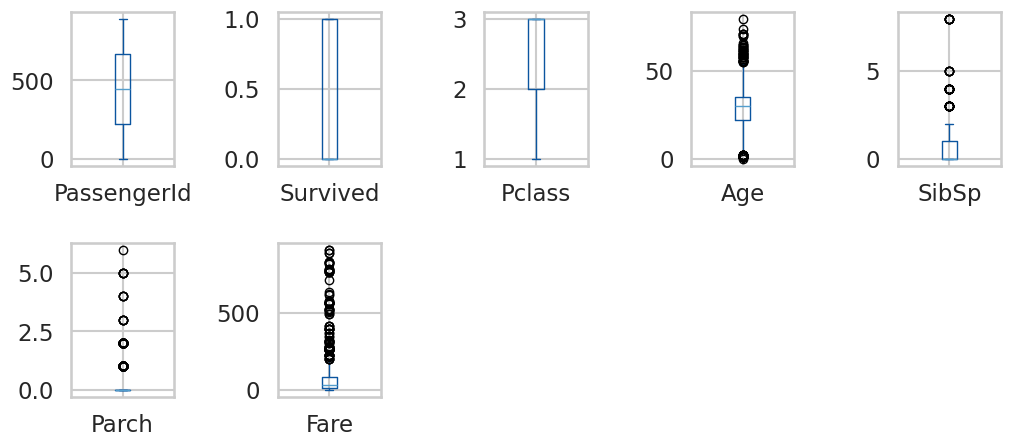

In [58]:
df_to_plot.plot(subplots=True, layout=(5,5), kind='box', figsize=(12,14))
plt.subplots_adjust(wspace=1, hspace=0.5)

semuanya masi makesense, pencilan2 yang ada jg masi masuk akal

##EDA
skip duls, kita pokus ke pembuatan model. beberapa step EDA sudah dilakukan skalian bersamaan pas proses cleaning data

##Modelling

###Preprocessing
1. Split data (ini ga perlu, krna uda udh di split dari sejak file)
2. Convert data ke Numberic
3. select featur (ini udah sambil berjalan, kita hapus yg ga diperlukan, seperti contohnya ticket, fare, dll)

####Convert Data to Numberic

#####Convert 'Sex'

In [59]:
# Convert 'Sex'
sex_mapping = {"male" : 0, "female" : 1}

df_train['Sex'] = df_train['Sex'].map(sex_mapping)
df_test['Sex'] = df_test['Sex'].map(sex_mapping)

In [60]:
df_train.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,712.833,C85,C


In [61]:
df_test.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",0,35.0,0,0,78.292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,7.000,NaN,S


#####Convert 'Embarked'

In [62]:
# One Hot Encoding (cara dummies)
embarked = df_train[['Embarked']]

dummies = pd.get_dummies(embarked).astype(int)
dummies.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1


In [63]:
df_train = pd.merge(df_train.reset_index(),  dummies.reset_index())
df_test = pd.merge(df_test.reset_index(),  dummies.reset_index())
df_test.head(2)

,index,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Embarked_C,Embarked_Q,Embarked_S
0,0,892,3,"Kelly, Mr. James",0,35.0,0,0,78.292,NaN,Q,0,0,1
1,1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,7.000,NaN,S,1,0,0


In [64]:
df_train.head(2)

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Embarked_C,Embarked_Q,Embarked_S
0,0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.250,NaN,S,0,0,1
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,712.833,C85,C,1,0,0


In [65]:
# kita hapus kolom Index dan Embarked yang lama (karena udh di convert jadi angka)
df_train = df_train.drop(["index",'Embarked'], axis =1 )
df_test = df_test.drop(["index",'Embarked'], axis =1 )

In [66]:
df_train.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.250,NaN,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,712.833,C85,1,0,0


In [67]:
df_test.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,892,3,"Kelly, Mr. James",0,35.0,0,0,78.292,NaN,0,0,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,7.000,NaN,1,0,0


#####Convert 'Title'
stelah diperhatikan, setiap nama memiliki gelar, baik itu Mr, atau Mrs, atau Miss dan lain lain. kita akan pisahkan title nya aja, terus kita urutkan kategori tersebut jadi suatu urutan (strata)

In [68]:
df_train['Title'] = df_train['Name'].str.extract(' ([A-Za-z]+)\.', expand = False)
df_test['Title'] = df_test['Name'].str.extract(' ([A-Za-z]+)\.', expand = False)
df_train.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.250,NaN,0,0,1,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,712.833,C85,1,0,0,Mrs


In [69]:
df_test.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S,Title
0,892,3,"Kelly, Mr. James",0,35.0,0,0,78.292,NaN,0,0,1,Mr
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,7.000,NaN,1,0,0,Mrs


In [70]:
# kita liat ada Title apa aja
df_train.Title.value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Mlle,2
Major,2
Col,2


In [71]:
df_test.Title.value_counts()

,count
Title,
Mr,240
Miss,78
Mrs,72
Master,21
Col,2
Rev,2
Ms,1
Dr,1
Dona,1


In [72]:
# Berdasarkan info dari internet, berikut urutan kastanya

# Nobilitas: Countess, Lady  4
# Gelar Kehormatan: Sir, Don, Dona  3
# Gelar Militer: Col, Major, Capt  2
# Gelar Akademik: Dr, Rev  1
# Gelar Kehormatan Lainnya: Jonkheer  0
# Gelar Umum: Mr, Ms, Mrs, Miss, Mlle, Mme, Master  0


title_mapping = {"Mr": 0, "Miss": 0, "Mrs": 0, "Mlle": 0, "Master": 0, "Dr": 1, "Rev": 1, "Col": 2, "Major": 2,"Countess": 4,
                 "Ms": 0, "Lady": 4, "Jonkheer": 0, "Don": 3, "Dona" : 3, "Mme": 0,"Capt": 2,"Sir": 3 }

df_train['Title'] = df_train['Title'].map(title_mapping)
df_test['Title'] = df_test['Title'].map(title_mapping)


####Select Feature

In [73]:
# karena pas modelling hanya memproses data numeric, kita drop feature yang ga diperlukan
df_train = df_train.drop(["PassengerId",'Name','Cabin'], axis = 1)
df_test = df_test.drop(["PassengerId",'Name','Cabin'], axis = 1 )

In [74]:
df_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Title
0,0,3,0,22.0,1,0,7.250,0,0,1,0
1,1,1,1,38.0,1,0,712.833,1,0,0,0
2,1,3,1,26.0,0,0,7.925,0,0,1,0
3,1,1,1,35.0,1,0,53.100,0,0,1,0
4,0,3,0,35.0,0,0,8.050,0,0,1,0


##Prediksi
kita uji coba dulu ML yang cocok untuk permasalahan ini dengan berbagai macam ML

In [75]:
df_train.shape, df_test.shape

((891, 11), (418, 10))

In [76]:
  # Importing Classifier Modules
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [77]:
train_data = df_train.drop("Survived",axis = 1)
target = df_train['Survived']

In [78]:
df_train.head(2)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Title
0,0,3,0,22.0,1,0,7.250,0,0,1,0
1,1,1,1,38.0,1,0,712.833,1,0,0,0


In [79]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_C  891 non-null    int64  
 8   Embarked_Q  891 non-null    int64  
 9   Embarked_S  891 non-null    int64  
 10  Title       891 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 76.7 KB


In [80]:
k_fold = KFold(n_splits=5 , shuffle=True, random_state=0) #<----- kfold ini teh berfungsi untuk nge split data. krna n_splits=5, artinya data ke split jdi 5

clf = GaussianNB()
scoring = 'accuracy'
score = cross_val_score(clf, train_data, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score.mean())

0.7654007909108028


Naive Bayes = 76%

In [81]:
k_fold = KFold(n_splits=5 , shuffle=True, random_state=0)

clf = DecisionTreeClassifier(random_state=0)
scoring = 'accuracy'
score = cross_val_score(clf, train_data, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score.mean())

0.7687966857071119


Decission Tree = 76%

In [82]:
k_fold = KFold(n_splits=5 , shuffle=True, random_state=42)

clf = RandomForestClassifier(random_state=42)
scoring = 'accuracy'
score = cross_val_score(clf, train_data, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.82681564 0.75842697 0.8258427  0.80337079 0.8258427 ]


In [83]:
score.mean()

0.8080597577051032

Random Forest = 80 %

In [84]:
k_fold = KFold(n_splits=5 , shuffle=True, random_state=0)

clf = KNeighborsClassifier()
scoring = 'accuracy'
score = cross_val_score(clf, train_data, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.75977654 0.67977528 0.67977528 0.68539326 0.73595506]


In [85]:
score.mean()

0.7081350825434687

KNeighbors = 70%

In [86]:
k_fold = KFold(n_splits=5 , shuffle=True, random_state=42)

clf = SVC(random_state=42)
scoring = 'accuracy'
score = cross_val_score(clf, train_data, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score.mean())

0.6453392756261377


SVC = 64%

Karena berdasarkan uji model diatas (sebelum ini), model skor tertinggi adalah ML RandomForestClassiefier dengan skor sebesar 80%, maka kita akan pakai yang ini. tapi untuk sebagai perbandingan, kita juga coba untuk pake ML lain, yaitu Decission Tree dan Naive Bayes

###Prediksi (Random Forest)

In [87]:
clf = RandomForestClassifier(random_state=42)
clf.fit(train_data, target)

RandomForestClassifier(random_state=42)

In [88]:
prediction = clf.predict(df_test)

In [89]:
df_testt = pd.read_csv(sheet_url_trf)  #<------ manggil ulang dataframe kita untuk digabungin sama hasil prediksi kita
submission = pd.DataFrame({"PassengerId": df_testt["PassengerId"], "Survived": prediction}) #<-- nah, ini buat mengolah hasil prediksi supaya mnjadi kolom
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0


In [90]:
submission.to_csv("submit(RF).csv", index = False)
df_testt['Survived'] = submission['Survived']
df_testt.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,78.292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7,NaN,S,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,96.875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,86.625,NaN,S,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,122.875,NaN,S,0


In [91]:
# coba kumpulkan di link kaggle nya 'https://www.kaggle.com/c/titanic'
# dan liat berapa skor nya

###Prediksi (Decision Tree)

In [92]:
clf = DecisionTreeClassifier(random_state=0)
clf.fit(train_data, target)

DecisionTreeClassifier(random_state=0)

In [93]:
prediction = clf.predict(df_test)

In [94]:
df_testtt = pd.read_csv(sheet_url_trf)  #<------ manggil ulang dataframe kita untuk digabungin sama hasil prediksi kita
submission = pd.DataFrame({"PassengerId": df_testtt["PassengerId"], "Survived": prediction}) #<-- nah, ini buat mengolah hasil prediksi supaya mnjadi kolom
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0


In [95]:
submission.to_csv("submit(DT).csv", index = False)
df_testtt['Survived'] = submission['Survived']
df_testtt.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,78.292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7,NaN,S,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,96.875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,86.625,NaN,S,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,122.875,NaN,S,0


In [96]:
# coba kumpulkan di link kaggle nya 'https://www.kaggle.com/c/titanic'
# dan liat berapa skor nya

###Prediksi (Naive Bayes)

In [97]:
clf = GaussianNB()
clf.fit(train_data, target)

GaussianNB()

In [98]:
prediction = clf.predict(df_test)

In [99]:
df_testttt = pd.read_csv(sheet_url_trf)  #<------ manggil ulang dataframe kita untuk digabungin sama hasil prediksi kita
submission = pd.DataFrame({"PassengerId": df_testttt["PassengerId"], "Survived": prediction}) #<-- nah, ini buat mengolah hasil prediksi supaya mnjadi kolom
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [100]:
submission.to_csv("submit(NB).csv", index = False)
df_testttt['Survived'] = submission['Survived']
df_testttt.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,78.292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7,NaN,S,1
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,96.875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,86.625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,122.875,NaN,S,1


In [102]:
target.value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838
